In [1]:
import os

import ipywidgets as widgets
import matplotlib
import numpy as np
from cil.framework import AcquisitionData, AcquisitionGeometry
from cil.io import TIFFStackReader
from cil.recon import FBP
from gvxrPython3 import gvxr
from matplotlib import pyplot as plt
from skimage.measure import profile_line
from utils import makeHollowCylinder, setPolySpectrum

# Configure matplotlib graph
font = {
    "family": "serif",
    "size": 15,
}
matplotlib.rc("font", **font)

# Uncomment the line below to use LaTeX fonts
# matplotlib.rc('text', usetex=True)

xpecgen is not install, you won't be able to load a beam spectrum using xpecgen


### Global variables

In [2]:
OUTPUT_PATH = "../../output_data/beam-hardening/"

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

### Create an OpenGL context

In [3]:
gvxr.createOpenGLContext()

Fri Aug 21 14:55:31 2026 ---- Create window (ID: -1)
Fri Aug 21 14:55:31 2026 ---- Request an interactive OpenGL context
Fri Aug 21 14:55:31 2026 ---- Initialise GLFW
Fri Aug 21 14:55:31 2026 (WW) GLFW error: X11: The DISPLAY environment variable is missing
Fri Aug 21 14:55:31 2026 (WW) Cannot initialise GLFW.
Fri Aug 21 14:55:31 2026 (WW) Could not create a context
Fri Aug 21 14:55:31 2026 ---- Request a EGL context
Fri Aug 21 14:55:31 2026 ---- Query the number of EGL devices
Fri Aug 21 14:55:31 2026 ---- Success
Fri Aug 21 14:55:31 2026 ---- Detected 4 EGL devices.
Fri Aug 21 14:55:31 2026 ---- Print the details here of every EGL device.
Fri Aug 21 14:55:31 2026 ---- Success
Fri Aug 21 14:55:31 2026 ---- Device 1/4:
Fri Aug 21 14:55:31 2026 ---- 	Device Extensions: EGL_NV_device_cuda EGL_EXT_device_drm EGL_EXT_device_drm_render_node EGL_EXT_device_query_name EGL_EXT_device_persistent_id
Fri Aug 21 14:55:31 2026 ---- 	EGL DRM device file: /dev/dri/card1
Fri Aug 21 14:55:31 2026 ---- 

###  Set up the detector

In [4]:
# Detector Position and direction
gvxr.setDetectorPosition(20.0, 0.0, 0.0, "cm")
gvxr.setDetectorUpVector(0, 0, -1)

# Detector Pixel definitions
gvxr.setDetectorNumberOfPixels(640, 640)
gvxr.setDetectorPixelSize(0.5, 0.5, "mm")

Fri Aug 21 14:55:31 2026 ---- Changed resolution


In [5]:
tube_voltage_kV = 100
tube_angle_degrees = 12
max_number_of_energy_bins = 100

filter_material = "Al"
filter_thickness = 1.0
filter_unit = "mm"

# No filter
# ---------
no_filter_hist = setPolySpectrum(
    tube_voltage_kV,
    filters=None,
    tube_angle_in_deg=tube_angle_degrees,
)

no_filter_bins, no_filter_photons = zip(*no_filter_hist.items(), strict=False)

Fri Aug 21 14:55:31 2026 (WW) addEnergyBinToSpectrum is deprecated. It will be removed in a future release. Choose addEnergyBinToSpectrumPerPixelAtSDD or addEnergyBinToSpectrumPerCm2At1m. Note that addEnergyBinToSpectrum and addEnergyBinToSpectrumPerPixelAtSDD are equivalent.


In [6]:
plt.close()

%matplotlib inline
def custom_filter_hist(
        material: str,
        thickness: float,
        unit: str,
        *,
        tube_voltage_kV : float,
        tube_angle_in_deg : float,
):
    filter_hist = setPolySpectrum(
        tube_voltage_kV,
        filters=[[material, thickness, unit]],
        tube_angle_in_deg=tube_angle_in_deg,
    )

    return zip(*filter_hist.items(), strict=False)



@widgets.interact(
        material=["Al", "Cu", "Sn"],
        thickness=(0, 3.0, 0.5),
        unit = ["mm","cm"],
        tube_voltage_kV = widgets.fixed(tube_voltage_kV),
        tube_angle_in_deg = widgets.fixed(tube_angle_degrees),
)
def update(material = "Al", thickness = 0.5, unit = "mm"):
    filter_bins,filter_photons = custom_filter_hist(
        material,
        thickness,
        unit,
        tube_voltage_kV=tube_voltage_kV,
        tube_angle_in_deg=tube_angle_degrees
    )
    # Plot all the spectra
    fig = plt.figure(figsize= (15,5), constrained_layout=True)
    fig.supxlabel("Energy (keV)")
    fig.supylabel("Probability distribution of photons per keV")

    plt.title(f"{thickness} {unit} {material}")
    plt.step(no_filter_bins,no_filter_photons,label="No filter")
    plt.step(filter_bins,filter_photons,label=f"{thickness} {unit} {material} filter")
    plt.legend()

    plt.show()

interactive(children=(Dropdown(description='material', options=('Al', 'Cu', 'Sn'), value='Al'), FloatSlider(va…

### Create a source

In [7]:
# Source position
gvxr.setSourcePosition(
    -20.0,
    0.0,
    0.0,
    "cm",
)

# gvxr.setMonoChromatic(100.0, "keV", 1000)

# Source type
gvxr.useParallelBeam()  # For a parallel source

Fri Aug 21 14:55:31 2026 ---- Mixed-precision flag: 255
Fri Aug 21 14:55:31 2026 ---- Unclean L-buffer precision: 32 bits
Fri Aug 21 14:55:31 2026 ---- Clean L-buffer precision: 32 bits
Fri Aug 21 14:55:31 2026 ---- Cumulative L-buffer precision: 32 bits
Fri Aug 21 14:55:31 2026 ---- Energy fluence precision: 32 bits
Fri Aug 21 14:55:31 2026 ---- Sum MuX dX precision: 32 bits
Fri Aug 21 14:55:31 2026 ---- Initialise the renderer with 32 bits per floating-point numbers in GPU memory


### Create an iron cylinder as main object source

In [8]:
gvxr.removePolygonMeshesFromSceneGraph()

material = "Al"

cylinder_height = 20
cylinder_outer_radius = 3
cylinder_inner_radius = 1
unit_of_length = "cm"

makeHollowCylinder(
    "hollow-cylinder",
    24,  # Number of sectors
    cylinder_height,
    cylinder_outer_radius,
    cylinder_inner_radius,
    unit_of_length,
)

gvxr.rotateNode("hollow-cylinder", 0, 0, 90)
gvxr.translateNode("hollow-cylinder", 0, 5, -3, unit_of_length)

gvxr.setElement("hollow-cylinder", material)
gvxr.addPolygonMeshAsOuterSurface("hollow-cylinder")

### Compute CT Acquisition Arguments
| Function Argument | Description |
|-------------------|-------------|
| `projection_output_path` | The path where the X-ray projections will be saved. If path is empty, data will be stored in main memory, but not saved on the disk. If path is provided, the data will be saved on the disk, and the main memory released. |
| `screenshot_output_path` | The path where the screenshots will be saved. If kept empty, not screenshot will be saved. |
| `num_of_projections` | The total number of projections to simulate. |
| `first_angle` | The rotation angle corresponding to the first projection. |
| `include_last_angle` | A boolean flag to include or exclude the last angle. It is used to calculate the angular step between successive projections. |
| `last_angle` | The number of white images used to perform the flat-field correction. If zero, then no correction will be performed. |
| `num_of_white_images_in_flat_field` | The location of the rotation centre. |
| `position_of_centre_of_rotation` | The corresponding unit of length. |
| `unit_of_length` | The rotation axis |
| `axis_of_rotation` | The upvector |
| `integrate_energy` | If true the energy fluence is returned, otherwise the number of photons is returned (default value: true) |

In [9]:
projection_output_path = os.path.join(OUTPUT_PATH, "cupping-recons")
screenshot_output_path = ""

num_of_projections = 503

first_angle = 0
include_last_angle = False
last_angle = 180

num_of_white_images_in_flat_field = 0

position_of_centre_of_rotation = (0, 0, 0)
unit_of_length = "cm"
axis_of_rotation = (0, 0, -1)

integrate_energy = True

gvxr.computeCTAcquisition(
    projection_output_path,
    screenshot_output_path,
    num_of_projections,
    first_angle,
    include_last_angle,
    last_angle,
    num_of_white_images_in_flat_field,
    *position_of_centre_of_rotation,
    unit_of_length,
    *axis_of_rotation,
    integrate_energy,
)

In [10]:
# Create the TIFF reader by passing the directory containing the files
reader = TIFFStackReader(
    file_name=os.path.join(OUTPUT_PATH, "cupping-recons"),
    dtype=np.float32,
)

# Read in file, and return a numpy array containing the data
data_original = reader.read()

# The data is stored as a stack of detector images, we use the CILlabels for the axes
axis_labels = ["angle", "vertical", "horizontal"]

# Normalisation
# Not strictly needed as the data was already corrected
data_normalised = data_original / data_original.max()

# Prevent log of a negative value
data_normalised[data_normalised < 1e-9] = 1e-9

# Linearisation
data_absorption = -np.log(data_normalised)

In [11]:
geometry = AcquisitionGeometry.create_Parallel3D(
    ray_direction=[1, 0, 0],
    detector_position=gvxr.getDetectorPosition("cm"),
    detector_direction_x=gvxr.getDetectorRightVector(),
    detector_direction_y=gvxr.getDetectorUpVector(),
    rotation_axis_position=gvxr.getCentreOfRotationPositionCT("cm"),
    rotation_axis_direction=gvxr.getRotationAxisCT(),
)

# Set the angles, remembering to specify the units
geometry.set_angles(
    np.array(gvxr.getAngleSetCT()),
    angle_unit="degree",
)

# Set the detector shape and size
geometry.set_panel(
    gvxr.getDetectorNumberOfPixels(),
    gvxr.getDetectorPixelSpacing("cm"),
)

# Set the order of the data
geometry.set_labels(axis_labels)

Working on the CPU, we cannot reconstruct the whole 3D volume for a cone beam geometry. Instead we reconstruct a single slice:

In [12]:
# Prepare the data for the reconstruction
acquisition_data = AcquisitionData(
    data_absorption,
    deep_copy=False,
    geometry=geometry,
)

ig = acquisition_data.geometry.get_ImageGeometry()

# get slice
data_slice = acquisition_data.get_slice(vertical="centre")

```{warning}
An NVIDIA GPU is required for the reconstruction using CIL
```

In [13]:
# Perform the FDK reconstruction
fbp =  FBP(acquisition_data, ig, backend="tigre")
recon = fbp.run()

FBP recon

Input Data:
	angle: 503
	vertical: 640
	horizontal: 640

Reconstruction Volume:
	vertical: 640
	horizontal_y: 640
	horizontal_x: 640

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



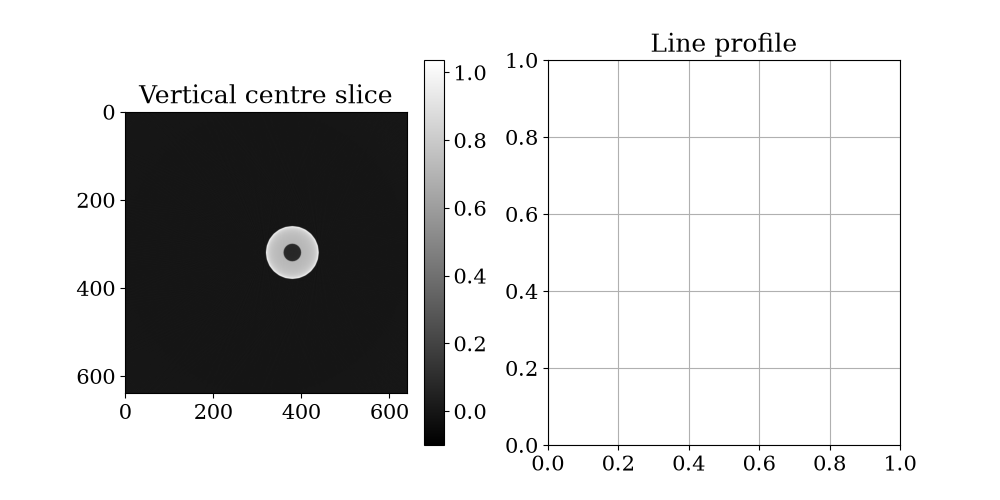

In [ ]:
plt.close("all")

%matplotlib widget
slice_array = recon.get_slice(vertical="centre").array

# Plot all the spectra
fig, ax = plt.subplots(1, 2, figsize=(10,5))
fig.canvas.layout.width = "100%"

ax[0].set(title="Vertical centre slice")
ax[1].set(title="Line profile")
ax[1].grid(True)

slice_image = ax[0].imshow(
    slice_array,
    cmap="grey",
    vmin=slice_array.min(),
    vmax=slice_array.max(),
)
fig.colorbar(slice_image, orientation="vertical")

clicks = []
axis_plots = []

def onclick(event):
    if event.inaxes is not ax[0]:
        return
    if len(clicks) >= 2:
        for artist in axis_plots:
            artist.remove()
        clicks.clear()
        axis_plots.clear()

    x_data, y_data = event.xdata, event.ydata
    clicks.append((x_data, y_data))

    point_plot = ax[0].plot(x_data, y_data, "yo", markersize=5)
    axis_plots.append(point_plot[0])

    if len(clicks) == 2:
        (x0, y0), (x1, y1) = clicks

        drawn_line = ax[0].plot((x0, x1), (y0, y1), "y-")
        line_profile = profile_line(slice_array, (y0, x0), (y1, x1))

        ax[1].set_xlim((0, line_profile.size + 1))
        ax[1].relim()
        ax[1].autoscale_view(scalex=False)

        line_profile_plot = ax[1].plot(line_profile, "c-")

        axis_plots.append(drawn_line[0])
        axis_plots.append(line_profile_plot[0])

    fig.canvas.draw()


cid = fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()